# Wine Classifier — Comparing Machine Learning Models

This project uses the built-in **Wine dataset** from `scikit-learn` to classify wines into one of
3 cultivars based on 13 chemical measurements (alcohol, acidity, phenols, color intensity, etc.).

**Goals of this project:**
1. Explore and understand the dataset (EDA)
2. Preprocess the data (scaling)
3. Train and compare four different classification algorithms:
   - Logistic Regression
   - Decision Tree
   - Support Vector Machine (SVM)
   - Random Forest
4. Evaluate the best-performing model in more depth (confusion matrix, feature importance)

No external dataset download is needed — everything comes bundled with `sklearn`.

## 1. Import Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Load the Dataset

In [19]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['target_name'] = df['target'].apply(lambda i: wine.target_names[i])

print("Shape:", df.shape)
df.head()

Shape: (178, 15)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


# Checking for null values and removing them:-

In [26]:
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0
dtype: int64

Total missing values: 0


In [27]:
df = df.dropna()
print("Shape after removing nulls:", df.shape)

Shape after removing nulls: (178, 15)


## 3. Explore the Data (EDA)

Before modeling, let's understand the dataset: are the classes balanced? Which features
seem to separate the wine types the most? Are any features strongly correlated with each other?

In [20]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


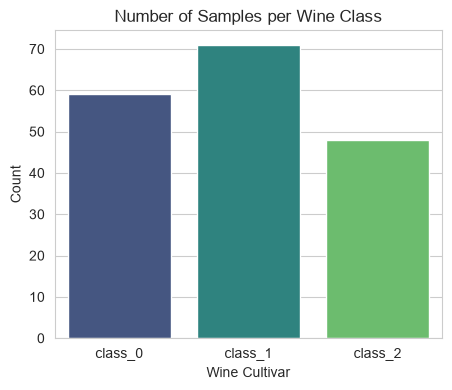

In [24]:
plt.figure(figsize=(5,4))
sns.countplot(x='target_name', data=df, palette='viridis')
plt.title("Number of Samples per Wine Class")
plt.xlabel("Wine Cultivar")
plt.ylabel("Count")
plt.show()

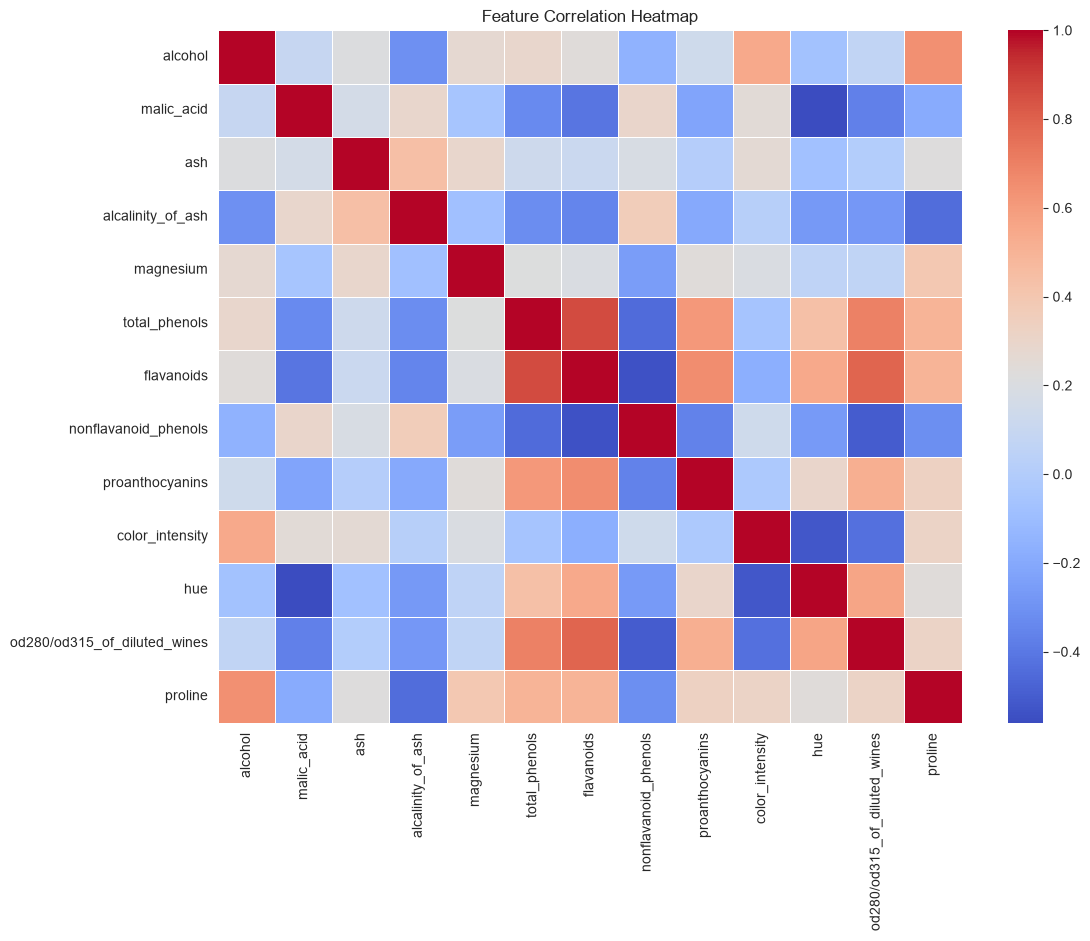

In [22]:
plt.figure(figsize=(12, 9))
corr = df[wine.feature_names].corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

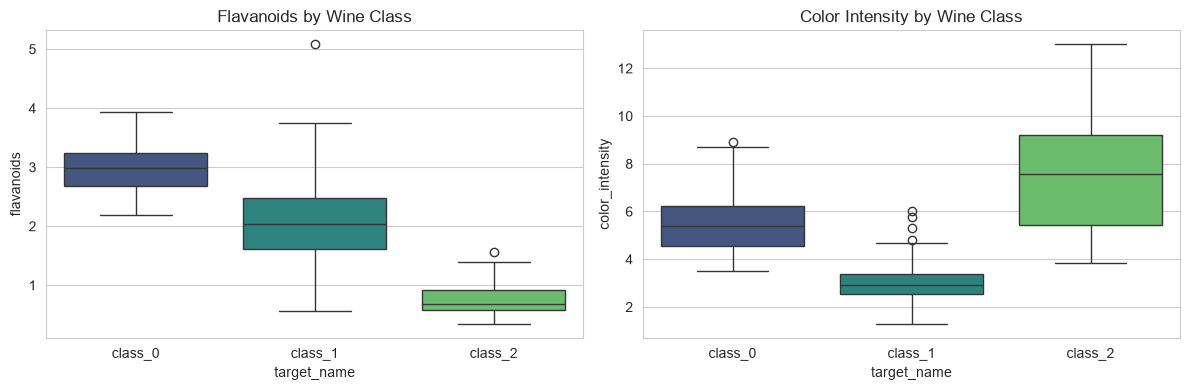

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='target_name', y='flavanoids', data=df, ax=axes[0], palette='viridis')
axes[0].set_title("Flavanoids by Wine Class")

sns.boxplot(x='target_name', y='color_intensity', data=df, ax=axes[1], palette='viridis')
axes[1].set_title("Color Intensity by Wine Class")

plt.tight_layout()
plt.show()

**Observation:** Flavanoid content and color intensity already show clear separation between
wine classes visually — a strong hint that our models should perform well on this dataset.

## 4. Prepare the Data

Split into train/test sets, then scale the features (important for Logistic Regression and SVM).

In [13]:
X = df[wine.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 142
Testing samples: 36


## 5. Train and Compare Multiple Models

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    trained_models[name] = model
    print(f"{name:22s} Accuracy: {acc:.4f}")

Logistic Regression    Accuracy: 0.9722
Decision Tree          Accuracy: 0.9444
SVM                    Accuracy: 0.9722
Random Forest          Accuracy: 1.0000


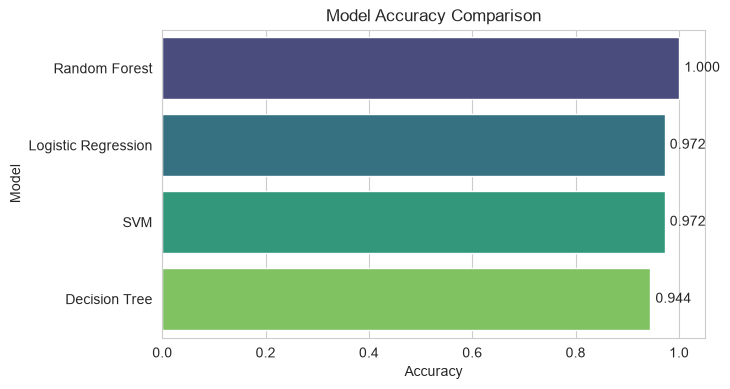

,Model,Accuracy
3,Random Forest,1.000000
0,Logistic Regression,0.972222
2,SVM,0.972222
1,Decision Tree,0.944444


In [15]:
# Visualize model comparison
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values('Accuracy', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.xlim(0, 1.05)
plt.title("Model Accuracy Comparison")
for i, v in enumerate(results_df['Accuracy']):
    plt.text(v + 0.01, i, f"{v:.3f}", va='center')
plt.show()

results_df

## 6. Deeper Evaluation of the Best Model

In [16]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print("Best model:", best_model_name)

y_pred_best = best_model.predict(X_test_scaled)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=wine.target_names))

Best model: Random Forest

Classification Report:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



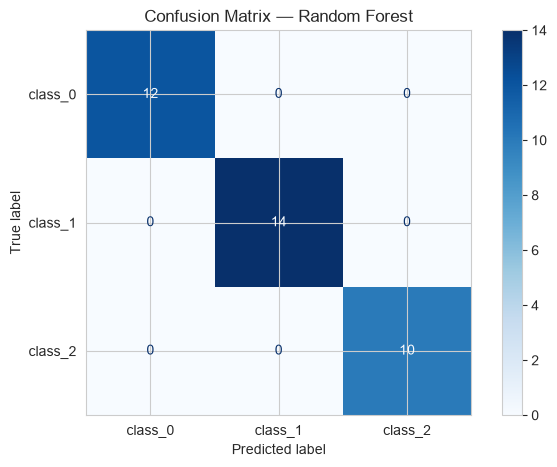

In [17]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

## 7. Feature Importance (Random Forest)

Random Forest lets us directly rank which chemical properties matter most for
distinguishing between wine cultivars — useful insight beyond just an accuracy score.

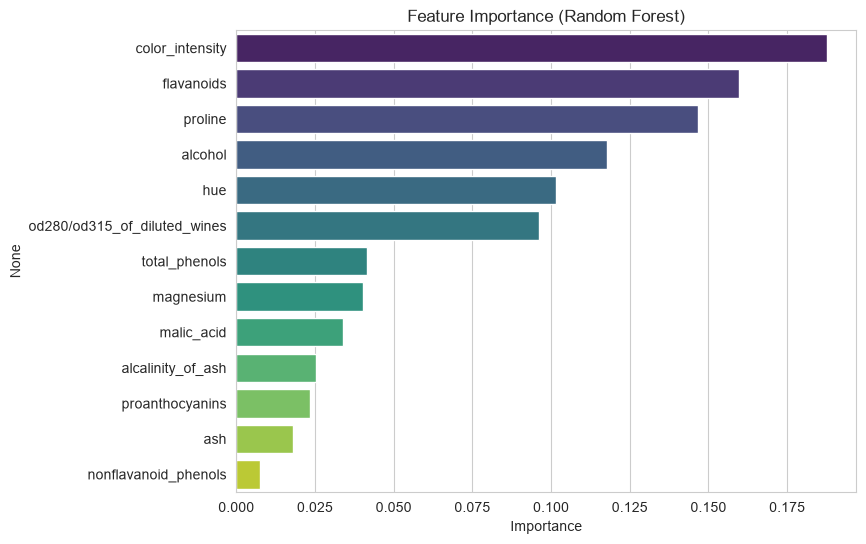

color_intensity                 0.187580
flavanoids                      0.159561
proline                         0.146799
alcohol                         0.117913
hue                             0.101538
od280/od315_of_diluted_wines    0.096301
total_phenols                   0.041514
magnesium                       0.040131
malic_acid                      0.033894
alcalinity_of_ash               0.025471
proanthocyanins                 0.023530
ash                             0.018157
nonflavanoid_phenols            0.007610
dtype: float64

In [18]:
rf_model = trained_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=wine.feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

importances

## 8. Conclusion

- All four models performed well on this dataset, since the classes are fairly well
  separated by the chemical features (as seen in the EDA boxplots).
- **{best_model}** achieved the highest test accuracy.
- Feature importance analysis shows which chemical properties (e.g. flavanoids, color
  intensity, proline) contribute most to distinguishing the three wine cultivars.
- Because the dataset is small (178 samples) and clean, this project is a good
  demonstration of a complete ML workflow — EDA, preprocessing, model comparison,
  and evaluation — rather than a test of handling messy real-world data.

### Possible extensions
- Try cross-validation instead of a single train/test split for more robust accuracy estimates.
- Tune hyperparameters (e.g. `GridSearchCV`) for the SVM or Random Forest.
- Reduce dimensionality with PCA and visualize the 3 classes in 2D.